In [95]:
import torch
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import torch.nn as nn
import sys

sys.path.append("/scratch/nar8991/snn/snn_ann_hybrid")

from class_based_implementation.models import SNN, ANN_with_LIF_output, Hybrid_RNN_SNN_rec, Hybrid_RNN_SNN_V1_same_layer, NSN_with_LIF_output, Hybrid_NSN_SNN_rec, Hybrid_NSN_SNN_V1_same_layer
from class_based_implementation.surr_grad import SurrGradSpike

from maren_data.helpers import choose_data_params

# Import the randman stuff from DarwinNeuron instead
sys.path.append("/scratch/nar8991/snn/DarwinNeuron")
from src.RandmanFunctions import RandmanConfig, split_and_load, split_test_and_load
import os

def compute_sam_sharpness(model, dataloader, rho=0.05, device='cuda'):
    """
    Computes the SAM loss at the trained model weights (the minimum),
    giving a scalar sharpness measure.
    """
    model.to(device)
    model.zero_grad()
    criterion = nn.CrossEntropyLoss()
    # 1. Compute vanilla gradients 
    total_loss = 0.0
    for inputs, targets in dataloader:
        inputs, targets = inputs.to(device), targets.to(device)
        predictions, _, _, _ = model(inputs)
        logit_output, _ = torch.max(predictions, dim=1)
        loss = criterion(logit_output, targets)
        loss.backward()
        total_loss += loss.item()

    # 2. Flatten gradients
    grad = torch.cat([p.grad.flatten().to(device) for p in model.parameters() if p.grad is not None])
    grad_norm = torch.norm(grad)
    if grad_norm == 0:
        # If gradient is zero, sharpness is zero
        return 0.0, 0.0

    # Add this normalization step
    normalized_grad = grad / grad_norm

    # 3. Perturb weights in the gradient direction (SAM)
    offset = 0
    with torch.no_grad():
        for p in model.parameters():
            if p.grad is None:
                continue
            numel = p.numel()
            epsilon = rho * normalized_grad[offset:offset+numel].view_as(p)
            p.add_(epsilon)
            offset += numel

    # 4. Evaluate loss at the perturbed weights
    sam_total_loss = 0.0
    for inputs, targets in dataloader:
        inputs, targets = inputs.to(device), targets.to(device)
        predictions, _, _, _ = model(inputs)
        logit_output, _ = torch.max(predictions, dim=1)
        sam_loss = criterion(logit_output, targets)
        sam_total_loss += sam_loss.item()
    avg_sam = sam_total_loss / len(dataloader)
    diff_sam = (sam_total_loss - total_loss) / len(dataloader) # Shifted the order!
    # 6. Return average SAM loss across the dataset
    return avg_sam, diff_sam


In [96]:
# Randman parameters
num_classes = 2
num_dim = 2
alpha = 3
nsn_reset_val = True # Generally True for now


import pandas as pd
def get_randman_data():
    meta_data_path = "/scratch/nar8991/snn/DarwinNeuron/data/randman/meta-data.csv"
    randman_dir = "/scratch/nar8991/snn/DarwinNeuron/data/randman"

    # Read metadata and select randman_id based on dim_manifold, num_classes, and alpha
    meta_df = pd.read_csv(meta_data_path)
    # Filter by dim_manifold and nb_classes
    filtered = meta_df[(meta_df["dim_manifold"] == num_dim) & (meta_df["nb_classes"] == num_classes)]

    if alpha is not None:
        filtered = filtered[filtered["alpha"] == alpha]
    if filtered.empty:
        raise ValueError(f"No randman dataset found for dim_manifold={num_dim}, num_classes={num_classes}, alpha={alpha}")
    randman_id = int(filtered.iloc[0]["id"])

    data_loader_config = {
        'randman_id': randman_id,
        'randman_dir': randman_dir
    }

    batch_size=516
    randman = RandmanConfig.lookup_by_id(data_loader_config['randman_id'], os.path.join(data_loader_config['randman_dir'], "meta-data.csv"))
    dataset = randman.read_dataset(data_loader_config['randman_dir'])
    train_loader, _ = split_and_load(dataset, batch_size=batch_size)
    return train_loader
def get_shd_train_data():
    pre_path_data = f"/scratch/nar8991/snn/snn_ann_hybrid/maren_data/shd/700_inputs/1.0_max_time/False_noise"
    settings = {}
    settings["max_time"] = 1
    settings["noise"] = False
    settings["time_step"] = 0.002
    settings["nb_inputs"] = 700
    settings["nb_outputs"] = 20
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    settings["device"] = device
    settings["dtype"] = torch.float32
    settings["batch_size"] = 256
    settings["percent_data"] = 1.0  # Use all data

    train_loader, _, _ = choose_data_params(
        "shd", settings, num_workers=0, pre_path=pre_path_data
        )
    return train_loader    

In [97]:
# Modified SAM

from loss_landscapes.sam_loss import compute_sam_sharpness 
from loss_landscapes.utils import get_randman_train_data
from test_visualizations.utils import compute_accuracy,get_randman_test_data, get_shd_test_data


from class_based_implementation.train_model import objective, MODEL_CLASSES, LOSS_FUNCTIONS # Import mappings too
def return_weights(model):
    weights = {}
    weights["w1_param"] = model.w1.data
    weights["w2_param"] = model.w2.data
    weights["v1_param"] = model.v1.data
    if model.gamma is not None:
        weights["gamma_param"] = model.gamma.data
    else:
        weights["gamma_param"] = None
    return weights
def calculate_and_visualize_sam(data, models_selected=None, sampler_type="grid", base_prefix="vast", percent_vals=[0.25, 0.5, 0.75], nsn_reset = True):
    if data == 'randman':
        # num_dim = 1
        # num_classes = 2
        # alpha = 3
        BASE_PATH=f"/{base_prefix}/nar8991/snn/training_results/randman/{num_dim}_d/{num_classes}_classes/3/cross_entropy"
        train_loader = get_randman_train_data(num_dim=num_dim, num_classes=num_classes, alpha=alpha)
        test_loader = get_randman_test_data(num_dim=num_dim, num_classes=num_classes, alpha=alpha)
        hidden_neurons = 20
    
    rho_list = [0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6]

    # Adjusted structure to store avg and diff SAM values separately for each rho
    sam_results = {
        'avg': {rho: [] for rho in rho_list},
        'diff': {rho: [] for rho in rho_list},
        'test_acc': {rho: [] for rho in rho_list},
        'train_acc': {rho: [] for rho in rho_list},
        'test_acc_bin': {rho: [] for rho in rho_list},
        'train_acc_bin': {rho: [] for rho in rho_list},
    }
    labels = []

    if models_selected is not None:
        new_model_classes = {k: v for k, v in MODEL_CLASSES.items() if k in models_selected}
    else:
        new_model_classes = MODEL_CLASSES

    missing = {}
    successful_models = {}
    
    for model_name, model_class in new_model_classes.items():
        missing[model_name] = {}
        successful_models[model_name] = {}
        
        for recurrent in ["True"]:
            percent_list = percent_vals if ('Hybrid' in model_name and 'Spiking' not in model_name) else [None]
            
            for percent in percent_list:
                missing[model_name][percent] = set()
                successful_models[model_name][percent] = set()
                seeds = range(1,11) if data == 'randman' else range(1,5)
                
                # Process each seed individually and create separate entries
                for seed in tqdm(seeds, desc=f"{model_name} | recurrent={recurrent} | {percent}_percent_snn"):
                    if "Flexible" in model_name:
                        prefix = "None_percent_snn/rand_gamma_init/gamma_fixed_False/"
                        if nsn_reset == False:
                            prefix = prefix + "reset_nsn_False/"
                        model_path_suffix = f"{prefix}best_model_of_study.ckpt"
                    elif "NSN" in model_name and nsn_reset == False:
                        model_path_suffix = f"{percent}_percent_snn/reset_nsn_False/best_model_of_study.ckpt"
                    else:
                        model_path_suffix = f"{percent}_percent_snn/best_model_of_study.ckpt"
                    
                    base_path = f"{BASE_PATH}/{model_name}/recurrent_{recurrent}/seed_{seed}/{sampler_type}_sampler/{hidden_neurons}_hidden/1.0_pct_data"
                    model_file_path = f"{base_path}/{model_path_suffix}"
                    
                    if not os.path.exists(model_file_path):
                        print(f"Skipping missing model file: {model_file_path}")
                        missing[model_name][percent].add(seed)
                        continue
                    
                    successful_models[model_name][percent].add(seed)
                    model = model_class.load_from_checkpoint(model_file_path, strict=False)
                    
                    if "Flexible" in model_name:
                        percent_snn = (n_spiking / (n_spiking + n_non_spiking)) if (n_spiking + n_non_spiking) > 0 else 0
                        weights = return_weights(model)
                        gamma_param = weights["gamma_param"]
                        n_spiking = (gamma_param > 0.5).sum().item()
                        n_non_spiking = (gamma_param <= 0.5).sum().item()
                
                        print(f"Model: {model_name} | Seed: {seed} | Spiking Neurons: {n_spiking} | Non-Spiking Neurons: {n_non_spiking}")
                    else:
                        percent_snn = percent
                    # Create seed-specific label
                    label = f"{model_name} | recurrent={recurrent} | {percent_snn}_percent_snn | seed={seed}"
                    labels.append(label)
                    
                    test_accuracy = compute_accuracy(model, test_loader)
                    train_accuracy = compute_accuracy(model, train_loader)
                    if "Flexible " in model_name:
                        # Post binarization accuracy
                        model.binarize_gamma()
                        test_accuracy_binarized = compute_accuracy(model, test_loader)
                        train_accuracy_binarized = compute_accuracy(model, train_loader)
                    else:
                        test_accuracy_binarized = test_accuracy
                        train_accuracy_binarized = train_accuracy
                    # Store single-seed data for each rho
                    for rho in rho_list:
                        avg_sam, diff_sam = compute_sam_sharpness(model, train_loader, rho=rho)
                        sam_results['avg'][rho].append([avg_sam])  # Single value in list
                        sam_results['diff'][rho].append([diff_sam])  # Single value in list
                        sam_results['test_acc'][rho].append([test_accuracy])  # Single value in list
                        sam_results['train_acc'][rho].append([train_accuracy])  # Single value in list
                        sam_results['test_acc_bin'][rho].append([test_accuracy_binarized])  # Single value in list
                        sam_results['train_acc_bin'][rho].append([train_accuracy_binarized])  # Single value in list


    return rho_list, sam_results, labels, missing, successful_models

In [98]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import re

# Helper function to plot box plots (aggregating by model label without seed)
def plot_sharpness_boxplots(sam_results, rho_list, labels):
    """
    Plots box plots for average and difference SAM sharpness.
    Aggregates by model label (removing '| seed=#'), and adds the count of seeds for each model as a label on the y-axis.
    """
    # Remove "| seed=..." from labels and aggregate indices
    label_base_list = []
    label_base_to_indices = {}
    for idx, label in enumerate(labels):
        # Remove "| seed=..." (with or without spaces)
        label_base = re.sub(r"\s*\|\s*seed\s*=\s*\d+", "", label)
        label_base_list.append(label_base)
        if label_base not in label_base_to_indices:
            label_base_to_indices[label_base] = []
        label_base_to_indices[label_base].append(idx)
    unique_label_bases = list(label_base_to_indices.keys())

    # Plotting for Average SAM Sharpness
    fig_avg, axes_avg = plt.subplots(1, len(rho_list), figsize=(18, 8), sharey=True)
    if len(rho_list) == 1:
        axes_avg = [axes_avg]
    for idx_rho, rho in enumerate(rho_list):
        ax = axes_avg[idx_rho]
        data_to_plot = []
        seed_counts = []
        for label_base in unique_label_bases:
            indices = label_base_to_indices[label_base]
            # Aggregate all seeds for this model label (across all seeds)
            values = []
            for i in indices:
                values.extend(np.atleast_1d(sam_results['avg'][rho][i]))
            data_to_plot.append(values)
            seed_counts.append(len(values))
        labels_with_counts = [f"{label}\n(n={count})" for label, count in zip(unique_label_bases, seed_counts)]
        ax.boxplot(data_to_plot, vert=False, positions=np.arange(len(unique_label_bases)))
        ax.set_yticks(np.arange(len(unique_label_bases)))
        ax.set_yticklabels(labels_with_counts)
        ax.set_title(f"rho={rho}")
        ax.set_xlabel("Average SAM Sharpness")
        if idx_rho == 0:
            ax.set_ylabel("Model | Recurrent\n(Seed count)")
    plt.suptitle("Average SAM Sharpness Across Models and Rhos", y=1.02)
    plt.tight_layout()
    plt.show()

    # Plotting for Difference SAM Sharpness
    fig_diff, axes_diff = plt.subplots(1, len(rho_list), figsize=(18, 8), sharey=True)
    if len(rho_list) == 1:
        axes_diff = [axes_diff]
    for idx_rho, rho in enumerate(rho_list):
        ax = axes_diff[idx_rho]
        data_to_plot = []
        seed_counts = []
        for label_base in unique_label_bases:
            indices = label_base_to_indices[label_base]
            values = []
            for i in indices:
                values.extend(np.atleast_1d(sam_results['diff'][rho][i]))
            data_to_plot.append(values)
            seed_counts.append(len(values))
        labels_with_counts = [f"{label}\n(n={count})" for label, count in zip(unique_label_bases, seed_counts)]
        ax.boxplot(data_to_plot, vert=False, positions=np.arange(len(unique_label_bases)))
        ax.set_yticks(np.arange(len(unique_label_bases)))
        ax.set_yticklabels(labels_with_counts)
        ax.set_title(f"rho={rho}")
        ax.set_xlabel("Difference SAM Sharpness")
        if idx_rho == 0:
            ax.set_ylabel("Model | Recurrent\n(Seed count)")
    plt.suptitle("Difference SAM Sharpness Across Models and Rhos", y=1.02)
    plt.tight_layout()
    plt.show()

# Helper function to calculate and plot similarity matrices for a single rho
def plot_single_rho_similarity(sam_results, rho, labels):
    """
    Calculates and plots Euclidean and Cosine similarity matrices for a single rho value.
    """
    if len(labels) <= 1:
        print(f"Not enough models to create similarity matrices for rho={rho}.")
        return

    # Create sharpness profiles for the current rho, based only on difference SAM
    current_rho_diff_profiles = np.array([
        [np.mean(sam_results['diff'][rho][model_idx])]
        for model_idx in range(len(labels))
    ])

    # Euclidean Distance-based Similarity Matrix
    distances = pdist(current_rho_diff_profiles, metric='euclidean')
    distance_matrix = squareform(distances)
    max_dist = np.max(distance_matrix)
    euclidean_similarity_matrix = 1 - (distance_matrix / max_dist) if max_dist > 0 else np.ones_like(distance_matrix)

    plt.figure(figsize=(12, 10))
    sns.heatmap(euclidean_similarity_matrix, annot=True, cmap='viridis', fmt=".2f",
                xticklabels=labels, yticklabels=labels,
                cbar_kws={'label': 'Euclidean Similarity (1 = most similar)'})
    plt.title(f"Model Sharpness Euclidean Similarity Matrix (Difference SAM for rho={rho})")
    plt.tight_layout()
    plt.show()

    # Cosine Similarity Matrix
    if not np.all(current_rho_diff_profiles == 0):
        cosine_sim_matrix = cosine_similarity(current_rho_diff_profiles)
        plt.figure(figsize=(12, 10))
        sns.heatmap(cosine_sim_matrix, annot=True, cmap='viridis', fmt=".2f",
                    xticklabels=labels, yticklabels=labels,
                    cbar_kws={'label': 'Cosine Similarity (1 = most similar, -1 = most dissimilar)'})
        plt.title(f"Model Sharpness Cosine Similarity Matrix (Difference SAM for rho={rho})")
        plt.tight_layout()
        plt.show()
    else:
        print(f"Skipping Cosine Similarity Matrix for rho={rho} due to all-zero profiles.")

# Helper function to calculate and plot overall similarity matrices across all rhos
def plot_overall_similarity(sam_results, rho_list, labels):
    """
    Calculates and plots overall Euclidean and Cosine similarity matrices across all rhos.
    """
    if len(labels) <= 1:
        print("Not enough models to create overall similarity matrices.")
        return

    model_profiles_across_rhos = np.array([
        [np.mean(sam_results['diff'][rho][model_idx]) for rho in rho_list]
        for model_idx in range(len(labels))
    ])

    # Euclidean Distance-based Overall Similarity Matrix
    distances_overall = pdist(model_profiles_across_rhos, metric='euclidean')
    distance_matrix_overall = squareform(distances_overall)
    max_dist_overall = np.max(distance_matrix_overall)
    euclidean_similarity_matrix_overall = 1 - (distance_matrix_overall / max_dist_overall) if max_dist_overall > 0 else np.ones_like(distance_matrix_overall)

    plt.figure(figsize=(12, 10))
    sns.heatmap(euclidean_similarity_matrix_overall, annot=True, cmap='viridis', fmt=".2f",
                xticklabels=labels, yticklabels=labels,
                cbar_kws={'label': 'Euclidean Similarity (1 = most similar)'})
    plt.title("Overall Model Sharpness Euclidean Similarity Matrix (Difference SAM across all Rhos)")
    plt.tight_layout()
    plt.show()

    # Cosine Similarity Overall Matrix
    if not np.all(model_profiles_across_rhos == 0):
        cosine_sim_matrix_overall = cosine_similarity(model_profiles_across_rhos)
        plt.figure(figsize=(12, 10))
        sns.heatmap(cosine_sim_matrix_overall, annot=True, cmap='viridis', fmt=".2f",
                    xticklabels=labels, yticklabels=labels,
                    cbar_kws={'label': 'Cosine Similarity (1 = most similar, -1 = most dissimilar)'})
        plt.title("Overall Model Sharpness Cosine Similarity Matrix (Difference SAM across all Rhos)")
        plt.tight_layout()
        plt.show()
    else:
        print("Skipping Overall Cosine Similarity Matrix due to all-zero profiles across rhos.")

# Helper function for PCA visualization
def plot_pca_visualization(sam_results, rho_list, labels):
    """
    Performs and visualizes PCA on the model sharpness profiles.
    Each individual data point for PCA is a single seed's sharpness profile
    (its difference SAM values across all rhos).
    This allows for multiple points per model configuration label.
    """
    if len(labels) <= 1:
        print("Not enough models to perform PCA visualization.")
        return

    pca_input_data = []
    corresponding_labels = []

    # First, determine the number of seeds present in the data for the first model/rho
    # This assumes a consistent number of seeds for all valid model/rho combinations.
    num_seeds = 0
    if rho_list and sam_results['diff'].get(rho_list[0]) and sam_results['diff'][rho_list[0]][0]:
        num_seeds = len(sam_results['diff'][rho_list[0]][0])

    if num_seeds == 0:
        print("No seed data found or inconsistent data structure. Cannot perform PCA with multiple points per label.")
        return

    # Loop through each unique model configuration (represented by 'labels')
    for model_idx, label in enumerate(labels):
        # For each model, gather the sharpness profiles for each seed
        for seed_idx in range(num_seeds):
            seed_profile = []
            is_seed_profile_valid = True
            for rho in rho_list:
                # Check if data exists for this specific rho, model, and seed
                if rho in sam_results['diff'] and model_idx < len(sam_results['diff'][rho]) \
                   and seed_idx < len(sam_results['diff'][rho][model_idx]):
                    seed_profile.append(sam_results['diff'][rho][model_idx][seed_idx])
                else:
                    # If any part of the profile is missing, this seed's profile is incomplete.
                    # We can choose to skip it or fill with a default value (e.g., 0).
                    # For PCA, it's generally better to have complete vectors.
                    # Let's fill with 0 for missing values, assuming it represents no sharpness.
                    seed_profile.append(0.0) 
            
            # Only add the profile if it's not entirely zeros (indicating actual data)
            # This handles cases where a model/seed combination might genuinely have all zero sharpness
            # or if it was partially missing and filled with zeros.
            if any(val != 0 for val in seed_profile): 
                pca_input_data.append(seed_profile)
                corresponding_labels.append(label)

    if not pca_input_data:
        print("No valid data points generated for PCA after filtering. Skipping PCA visualization.")
        return

    pca_input_data = np.array(pca_input_data)

    if pca_input_data.shape[0] < 2:
        print("Not enough samples (less than 2) for PCA visualization after filtering. Skipping PCA.")
        return
    if pca_input_data.shape[1] < 2:
        print(f"Not enough features (dimensions) for PCA (need at least 2, got {pca_input_data.shape[1]}). Skipping PCA.")
        return
    
    # Check if all data points are identical after scaling, which would break PCA
    # Calculate variance for each feature (column)
    feature_variances = np.var(pca_input_data, axis=0)
    # If all feature variances are effectively zero, PCA will fail
    if np.all(np.isclose(feature_variances, 0)):
        print("All data points are identical or have zero variance. PCA not meaningful. Skipping PCA visualization.")
        return

    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(pca_input_data)
    
    # Determine the number of components to use for PCA
    # min(number of samples - 1, number of features, 2)
    n_components_to_use = min(scaled_data.shape[0] - 1, scaled_data.shape[1], 2)
    
    if n_components_to_use < 2:
        print(f"Not enough dimensions ({n_components_to_use} available) to perform a 2D PCA for visualization. Skipping PCA.")
        return

    pca = PCA(n_components=n_components_to_use)
    principal_components = pca.fit_transform(scaled_data)

    plt.figure(figsize=(14, 10)) # Increased figure size
    unique_labels = sorted(list(set(corresponding_labels)))
    colors = plt.cm.get_cmap('tab20', len(unique_labels)) # Use tab20 for more distinct colors

    for i, label in enumerate(unique_labels):
        # Find indices for the current label in the corresponding_labels list
        idx = [j for j, l in enumerate(corresponding_labels) if l == label]
        
        # Plot all points belonging to this label
        plt.scatter(principal_components[idx, 0], principal_components[idx, 1],
                    label=label, color=colors(i % 20), alpha=0.7, s=80, # Use modulo for color cycling
                    edgecolors='w', linewidth=0.5) # Add white edge for better visibility

    plt.xlabel(f"Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.2f}%)", fontsize=12)
    plt.ylabel(f"Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.2f}%)", fontsize=12)
    plt.title("PCA of Model Sharpness Profiles (Difference SAM across all Rhos)", fontsize=14)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10) # Move legend outside plot
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjust layout to make space for the legend
    plt.show()

# Main refactored function
def plot_sam_results(rho_list, sam_results, labels):
    """
    Master function to plot SAM results, including sharpness boxplots,
    similarity matrices, and PCA visualization.
    """
    # 1. Plot sharpness distributions using box plots
    plot_sharpness_boxplots(sam_results, rho_list, labels)

    # # 2. Plot similarity matrices for each rho
    # for rho in rho_list:
    #     plot_single_rho_similarity(sam_results, rho, labels)

    # # 3. Plot overall similarity matrices across all rhos
    # plot_overall_similarity(sam_results, rho_list, labels)

    # # 4. Perform and plot PCA
    # plot_pca_visualization(sam_results, rho_list, labels)

In [99]:
# import pandas as pd
# import glob

# csv_dir = "/scratch/nar8991/snn/output/sam_results_csv_final"
# csv_files = glob.glob(f"{csv_dir}/*.csv")

# # Read and concatenate all CSVs
# df_all = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)
# # Sort by model_name and percent (percent_snn)
# df_all = df_all.sort_values(by=["model_name", "percent"]).reset_index(drop=True)

# # Assume columns: 'model', 'recurrent', 'percent', 'rho', 'avg_sam', 'diff_sam', 'seed'
# rho_list = sorted(df_all['rho'].unique())
# labels = []
# label_map = {}

# for _, row in df_all.iterrows():
#     percent_str = f"{row['percent']}_percent_snn" if pd.notnull(row['percent']) else ""
#     label = f"{row['model_name']} | recurrent={row['recurrent']}" + (f" | {percent_str}" if percent_str else "")
#     if label not in label_map:
#         label_map[label] = len(labels)
#         labels.append(label)

# # Build sam_results dict
# sam_results = {
#     'avg': {rho: [[] for _ in labels] for rho in rho_list},
#     'diff': {rho: [[] for _ in labels] for rho in rho_list}
# }

# for _, row in df_all.iterrows():
#     percent_str = f"{row['percent']}_percent_snn" if pd.notnull(row['percent']) else ""
#     label = f"{row['model_name']} | recurrent={row['recurrent']}" + (f" | {percent_str}" if percent_str else "")
#     idx = label_map[label]
#     rho = row['rho']
#     sam_results['avg'][rho][idx].append(row['avg_sam'])
#     sam_results['diff'][rho][idx].append(row['diff_sam'])

In [100]:
"/vast/nar8991/snn/training_results/randman/1_d/2_classes/3/cross_entropy/NSN_with_LIF_output/recurrent_True/seed_1/tpe_sampler/20_hidden/1.0_pct_data/best_model_of_study.ckpt"
"/vast/nar8991/snn/training_results/randman/1_d/2_classes/3/cross_entropy/NSN_with_LIF_output/recurrent_True/seed_1/tpe_sampler/20_hidden/1.0_pct_data/None_percent_snn/best_model_of_study.ckpt"
# plot_sam_results(rho_list, sam_results, labels)

'/vast/nar8991/snn/training_results/randman/1_d/2_classes/3/cross_entropy/NSN_with_LIF_output/recurrent_True/seed_1/tpe_sampler/20_hidden/1.0_pct_data/None_percent_snn/best_model_of_study.ckpt'

In [ ]:
# Adjust this so it's V1 only
models = ["SNN", "Hybrid_NSN_SNN_V1_same_layer", "NSN_with_LIF_output"]
rho_list, sam_results, labels, missing, successful = calculate_and_visualize_sam("randman", models_selected=models, sampler_type="tpe", base_prefix="vast", percent_vals=[0.25, 0.5, 0.75, 0.8, 0.85, 0.9, 0.95], nsn_reset=nsn_reset_val)

Testing: 100%|██████████| 3/3 [00:00<00:00, 23.27it/s]
SNN | recurrent=True | None_percent_snn: 100%|██████████| 10/10 [00:12<00:00,  1.29s/it]


Skipping missing model file: /vast/nar8991/snn/training_results/randman/2_d/2_classes/3/cross_entropy/SNN/recurrent_True/seed_6/tpe_sampler/20_hidden/1.0_pct_data/None_percent_snn/best_model_of_study.ckpt
Skipping missing model file: /vast/nar8991/snn/training_results/randman/2_d/2_classes/3/cross_entropy/SNN/recurrent_True/seed_7/tpe_sampler/20_hidden/1.0_pct_data/None_percent_snn/best_model_of_study.ckpt
Skipping missing model file: /vast/nar8991/snn/training_results/randman/2_d/2_classes/3/cross_entropy/SNN/recurrent_True/seed_8/tpe_sampler/20_hidden/1.0_pct_data/None_percent_snn/best_model_of_study.ckpt
Skipping missing model file: /vast/nar8991/snn/training_results/randman/2_d/2_classes/3/cross_entropy/SNN/recurrent_True/seed_9/tpe_sampler/20_hidden/1.0_pct_data/None_percent_snn/best_model_of_study.ckpt
Skipping missing model file: /vast/nar8991/snn/training_results/randman/2_d/2_classes/3/cross_entropy/SNN/recurrent_True/seed_10/tpe_sampler/20_hidden/1.0_pct_data/None_percent_snn

Testing: 100%|██████████| 3/3 [00:00<00:00, 35.50it/s]
NSN_with_LIF_output | recurrent=True | None_percent_snn: 100%|██████████| 10/10 [00:11<00:00,  1.19s/it]


Skipping missing model file: /vast/nar8991/snn/training_results/randman/2_d/2_classes/3/cross_entropy/NSN_with_LIF_output/recurrent_True/seed_6/tpe_sampler/20_hidden/1.0_pct_data/None_percent_snn/best_model_of_study.ckpt
Skipping missing model file: /vast/nar8991/snn/training_results/randman/2_d/2_classes/3/cross_entropy/NSN_with_LIF_output/recurrent_True/seed_7/tpe_sampler/20_hidden/1.0_pct_data/None_percent_snn/best_model_of_study.ckpt
Skipping missing model file: /vast/nar8991/snn/training_results/randman/2_d/2_classes/3/cross_entropy/NSN_with_LIF_output/recurrent_True/seed_8/tpe_sampler/20_hidden/1.0_pct_data/None_percent_snn/best_model_of_study.ckpt
Skipping missing model file: /vast/nar8991/snn/training_results/randman/2_d/2_classes/3/cross_entropy/NSN_with_LIF_output/recurrent_True/seed_9/tpe_sampler/20_hidden/1.0_pct_data/None_percent_snn/best_model_of_study.ckpt
Skipping missing model file: /vast/nar8991/snn/training_results/randman/2_d/2_classes/3/cross_entropy/NSN_with_LIF_o

Testing: 100%|██████████| 3/3 [00:00<00:00,  7.95it/s]
Hybrid_NSN_SNN_V1_same_layer | recurrent=True | 0.25_percent_snn: 100%|██████████| 10/10 [00:28<00:00,  2.80s/it]
Testing: 100%|██████████| 3/3 [00:00<00:00, 27.62it/s]
Hybrid_NSN_SNN_V1_same_layer | recurrent=True | 0.5_percent_snn:  40%|████      | 4/10 [00:12<00:17,  3.00s/it]

Skipping missing model file: /vast/nar8991/snn/training_results/randman/2_d/2_classes/3/cross_entropy/Hybrid_NSN_SNN_V1_same_layer/recurrent_True/seed_5/tpe_sampler/20_hidden/1.0_pct_data/0.5_percent_snn/best_model_of_study.ckpt


Testing: 100%|██████████| 3/3 [00:00<00:00, 27.64it/s]
Hybrid_NSN_SNN_V1_same_layer | recurrent=True | 0.5_percent_snn: 100%|██████████| 10/10 [00:27<00:00,  2.77s/it]
Testing: 100%|██████████| 3/3 [00:00<00:00, 27.88it/s]
Hybrid_NSN_SNN_V1_same_layer | recurrent=True | 0.75_percent_snn:  80%|████████  | 8/10 [00:21<00:05,  2.71s/it]

Skipping missing model file: /vast/nar8991/snn/training_results/randman/2_d/2_classes/3/cross_entropy/Hybrid_NSN_SNN_V1_same_layer/recurrent_True/seed_9/tpe_sampler/20_hidden/1.0_pct_data/0.75_percent_snn/best_model_of_study.ckpt


Testing: 100%|██████████| 3/3 [00:00<00:00, 27.68it/s]
Hybrid_NSN_SNN_V1_same_layer | recurrent=True | 0.75_percent_snn: 100%|██████████| 10/10 [00:24<00:00,  2.44s/it]
Testing: 100%|██████████| 3/3 [00:00<00:00, 19.83it/s]


In [ ]:
missing

{'SNN': {None: set()},
 'NSN_with_LIF_output': {None: set()},
 'Hybrid_NSN_SNN_V1_same_layer': {0.25: set(),
  0.5: set(),
  0.75: set(),
  0.8: set(),
  0.85: set(),
  0.9: set(),
  0.95: set()}}

In [ ]:
# TO DO: save as function and then run with SHD (also add function to generate missing data)
def update_missing_experiments_csv(missing, existing_csv_file="missing_experiments.csv", 
                                 data="randman", dim_manifold=1, num_classes=2, alpha=3, 
                                 sampler_type="tpe", gamma_init_type="rand", 
                                 gamma_fixed=False, reset_nsn=True, no_non_recurrent=True,
                                 output_file=None):
    """
    Generate a CSV file with missing experiment configurations based on the missing dictionary.
    """
    missing_rows = []

    if output_file is None:
        output_file = existing_csv_file  # Update in place
    
    # Read existing CSV if it exists
    try:
        df_existing = pd.read_csv(existing_csv_file)
        print(f"Loaded existing CSV with {len(df_existing)} experiments")
    except FileNotFoundError:
        print(f"No existing CSV found at {existing_csv_file}, creating new one")
        df_existing = pd.DataFrame()

    # Filter the existing DataFrame to only include relevant rows
    if not df_existing.empty:
        df_existing_filtered = df_existing[
            (df_existing['data'] == data) &
            (df_existing['dim_manifold'] == dim_manifold) &
            (df_existing['num_classes'] == num_classes) &
            (df_existing['alpha'] == alpha) &
            (df_existing['sampler_type'] == sampler_type) &
            (df_existing['gamma_init_type'] == gamma_init_type) &
            (df_existing['gamma_fixed'] == gamma_fixed) &
            (df_existing['reset_nsn'] == reset_nsn) &
            (df_existing['no_non_recurrent'] == no_non_recurrent)
        ]
        print(f"Filtered existing CSV to {len(df_existing_filtered)} relevant experiments")

    # See if any of the missing experiments are no longer missing (i.e., in CSV but no longer there)
    
    for model_name, percent_dict in missing.items():
        for percent, missing_seeds in percent_dict.items():
            if missing_seeds:  # Only process if there are missing seeds
                for seed in missing_seeds:
                    # Handle percent_snn formatting
                    if percent is None:
                        percent_snn_str = ""
                    else:
                        percent_snn_str = str(percent)
                    
                    # Create a row for this missing experiment
                    row = {
                        'data': data,
                        'dim_manifold': dim_manifold,
                        'num_classes': num_classes,
                        'alpha': alpha,
                        'chosen_model': model_name,
                        'sweep_seed': seed,
                        'percent_snn': percent_snn_str,
                        'sampler_type': sampler_type,
                        'gamma_init_type': gamma_init_type,
                        'gamma_fixed': gamma_fixed,
                        'reset_nsn': reset_nsn,
                        'no_non_recurrent': no_non_recurrent,
                        'n_trials': 21  # Default value
                    }
                    missing_rows.append(row)
                    # Check if this row already exists in the existing filtered DataFrame
                    if not df_existing.empty:
                        # Define the condition for experiment existence as a function for reuse
                        def experiment_exists(df, data, dim_manifold, num_classes, alpha, model_name, seed, percent_snn_str, sampler_type, gamma_init_type, gamma_fixed, reset_nsn, no_non_recurrent):
                            return (
                                (df['data'] == data) &
                                (df['dim_manifold'] == dim_manifold) &
                                (df['num_classes'] == num_classes) &
                                (df['alpha'] == alpha) &
                                (df['chosen_model'] == model_name) &
                                (df['sweep_seed'] == seed) &
                                (df['percent_snn'] == percent_snn_str) &
                                (df['sampler_type'] == sampler_type) &
                                (df['gamma_init_type'] == gamma_init_type) &
                                (df['gamma_fixed'] == gamma_fixed) &
                                (df['reset_nsn'] == reset_nsn) &
                                (df['no_non_recurrent'] == no_non_recurrent)
                            ).any()

                        exists = experiment_exists(
                            df_existing_filtered, data, dim_manifold, num_classes, alpha, model_name, seed, percent_snn_str,
                            sampler_type, gamma_init_type, gamma_fixed, reset_nsn, no_non_recurrent
                        )
                        if exists:
                            print(f"Experiment already exists in CSV, skipping: {row}")
                            missing_rows.pop()  # Remove the last added row since it exists
                            # Also pop it from df_existing (not filtered)
                            df_existing = df_existing[~experiment_exists(
                                df_existing, data, dim_manifold, num_classes, alpha, model_name, seed, percent_snn_str,
                                sampler_type, gamma_init_type, gamma_fixed, reset_nsn, no_non_recurrent
                            )]        

    # Add new missing rows to the existing DataFrame
    if missing_rows:
        df_missing = pd.DataFrame(missing_rows)
        if not df_existing.empty:
            df_updated = pd.concat([df_existing, df_missing], ignore_index=True)
        else:
            df_updated = df_missing
        df_updated.to_csv(output_file, index=False)
        print(f"Generated {len(missing_rows)} missing experiment configurations in '{output_file}'")
        return df_missing
    else:
        print("No missing experiments found!")
        return pd.DataFrame()

# Use it with your missing data
df_missing = update_missing_experiments_csv(
    missing, 
    data="randman",
    dim_manifold=num_dim,
    num_classes=num_classes,
    alpha=alpha,
    sampler_type="tpe",
    reset_nsn=nsn_reset_val,  # Based on your nsn_reset=False parameter
    # output_file="missing_randman_experiments.csv"

)

# Display the missing experiments
print(f"Missing experiments summary:")
for model_name, percent_dict in missing.items():
    for percent, missing_seeds in percent_dict.items():
        if missing_seeds:
            print(f"  {model_name} (percent={percent}): seeds {sorted(missing_seeds)}")

# Show the generated DataFrame
if not df_missing.empty:
    print("\nGenerated CSV content:")
    display(df_missing)

Loaded existing CSV with 176 experiments
Filtered existing CSV to 45 relevant experiments
No missing experiments found!
Missing experiments summary:


In [ ]:
missing

{'SNN': {None: set()},
 'NSN_with_LIF_output': {None: set()},
 'Hybrid_NSN_SNN_V1_same_layer': {0.25: set(),
  0.5: set(),
  0.75: set(),
  0.8: set(),
  0.85: set(),
  0.9: set(),
  0.95: set()}}

In [ ]:
missing

{'SNN': {None: set()},
 'NSN_with_LIF_output': {None: set()},
 'Hybrid_NSN_SNN_V1_same_layer': {0.25: set(),
  0.5: set(),
  0.75: set(),
  0.8: set(),
  0.85: set(),
  0.9: set(),
  0.95: set()}}

In [ ]:
labels

['SNN | recurrent=True | None_percent_snn | seed=1',
 'SNN | recurrent=True | None_percent_snn | seed=2',
 'SNN | recurrent=True | None_percent_snn | seed=3',
 'SNN | recurrent=True | None_percent_snn | seed=4',
 'SNN | recurrent=True | None_percent_snn | seed=5',
 'SNN | recurrent=True | None_percent_snn | seed=6',
 'SNN | recurrent=True | None_percent_snn | seed=7',
 'SNN | recurrent=True | None_percent_snn | seed=8',
 'SNN | recurrent=True | None_percent_snn | seed=9',
 'SNN | recurrent=True | None_percent_snn | seed=10',
 'NSN_with_LIF_output | recurrent=True | None_percent_snn | seed=1',
 'NSN_with_LIF_output | recurrent=True | None_percent_snn | seed=2',
 'NSN_with_LIF_output | recurrent=True | None_percent_snn | seed=3',
 'NSN_with_LIF_output | recurrent=True | None_percent_snn | seed=4',
 'NSN_with_LIF_output | recurrent=True | None_percent_snn | seed=5',
 'NSN_with_LIF_output | recurrent=True | None_percent_snn | seed=6',
 'NSN_with_LIF_output | recurrent=True | None_percent_s

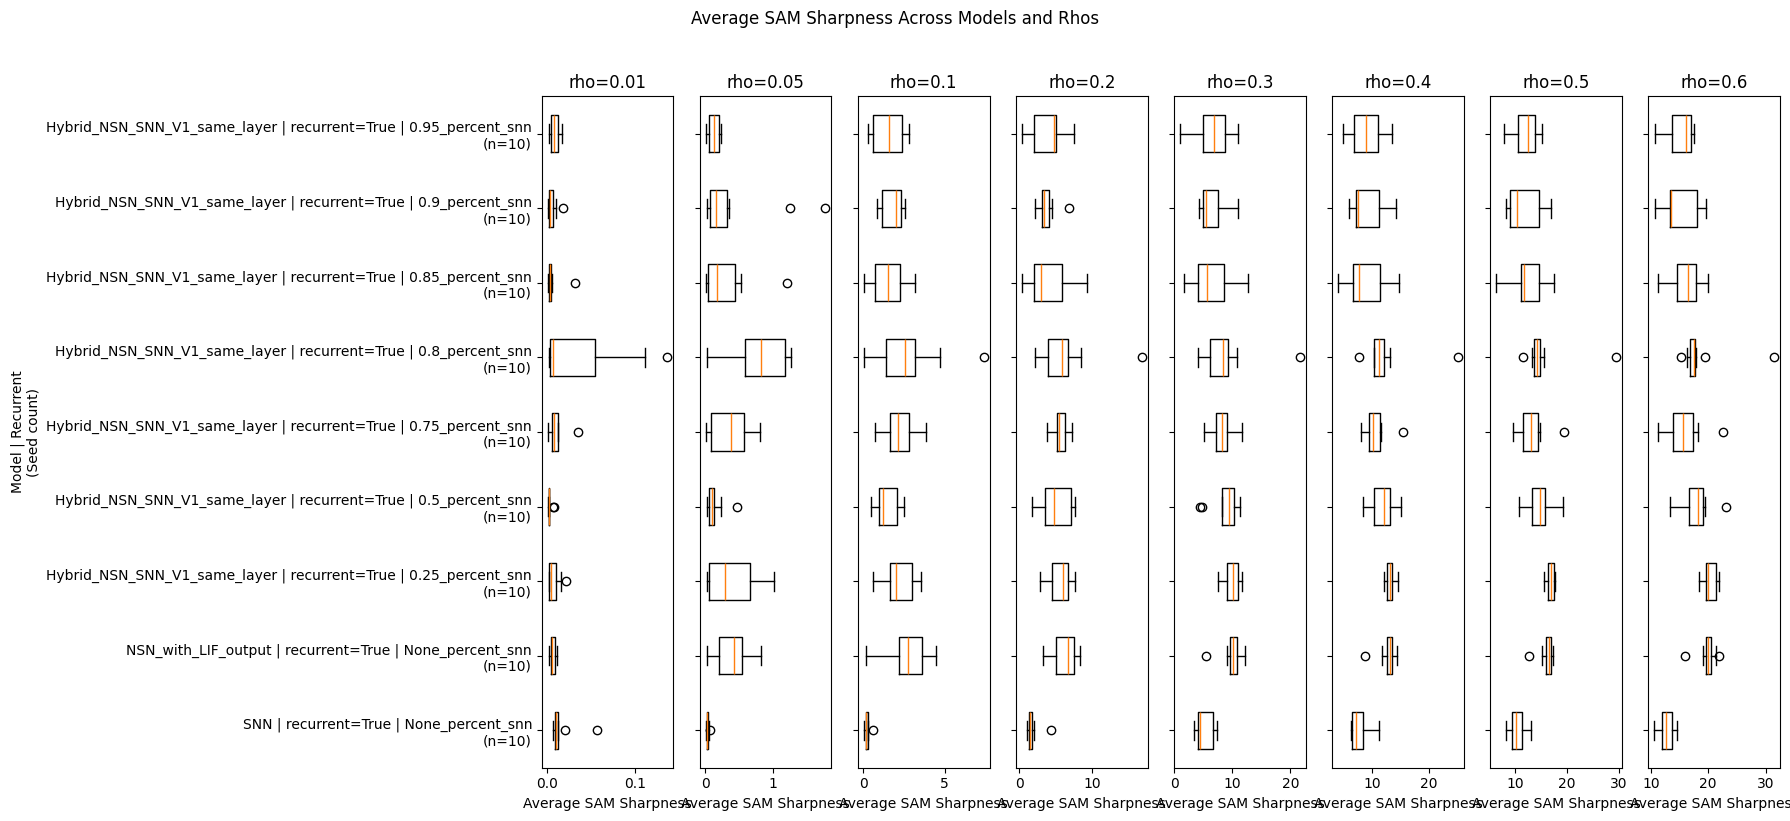

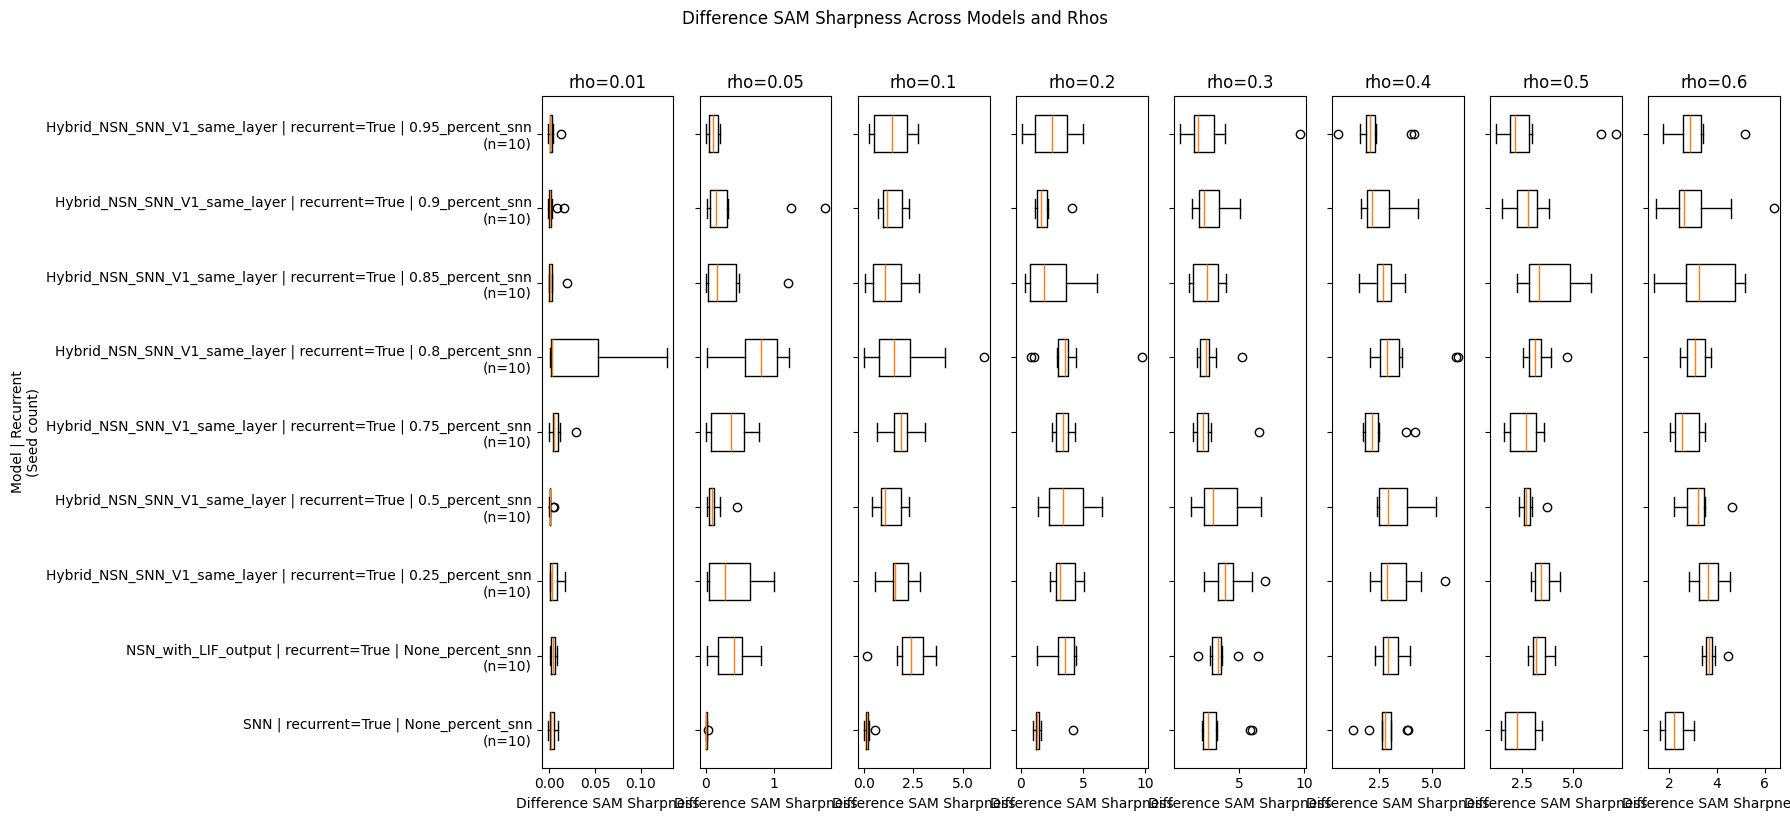

In [ ]:
plot_sam_results(rho_list, sam_results, labels)

# Rerunning with flexible spiking conditional

In [ ]:
def conversion_df(sam_results, rho_list, labels):
    data = []
    for model_idx, label in enumerate(labels):
        for rho in rho_list:
            avg_vals = sam_results['avg'][rho][model_idx]
            diff_vals = sam_results['diff'][rho][model_idx]
            train_accuracy = sam_results['train_acc'][rho][model_idx]
            test_accuracy = sam_results['test_acc'][rho][model_idx]
            for avg, diff in zip(avg_vals, diff_vals):
                data.append({
                    'model': label,
                    'rho': rho,
                    'avg_sam': avg,
                    'diff_sam': diff,
                    'train_accuracy': train_accuracy,
                    'test_accuracy': test_accuracy
                })
    return pd.DataFrame(data)

df_final = conversion_df(sam_results, rho_list, labels)

In [ ]:
df_final

,model,rho,avg_sam,diff_sam,train_accuracy,test_accuracy
0,SNN | recurrent=True | None_percent_snn | seed=1,0.01,0.057110,0.006084,[0.9925000071525574],[0.987500011920929]
1,SNN | recurrent=True | None_percent_snn | seed=1,0.05,0.064273,0.006540,[0.9925000071525574],[0.987500011920929]
2,SNN | recurrent=True | None_percent_snn | seed=1,0.10,0.216334,0.151189,[0.9925000071525574],[0.987500011920929]
3,SNN | recurrent=True | None_percent_snn | seed=1,0.20,4.381480,4.179264,[0.9925000071525574],[0.987500011920929]
4,SNN | recurrent=True | None_percent_snn | seed=1,0.30,7.359433,3.075009,[0.9925000071525574],[0.987500011920929]
...,...,...,...,...,...,...
715,Hybrid_NSN_SNN_V1_same_layer | recurrent=True ...,0.20,5.419533,3.510518,[1.0],[0.9975000023841858]
716,Hybrid_NSN_SNN_V1_same_layer | recurrent=True ...,0.30,8.787006,3.363426,[1.0],[0.9975000023841858]
717,Hybrid_NSN_SNN_V1_same_layer | recurrent=True ...,0.40,11.285502,2.097146,[1.0],[0.9975000023841858]
718,Hybrid_NSN_SNN_V1_same_layer | recurrent=True ...,0.50,13.318610,2.115431,[1.0],[0.9975000023841858]


In [ ]:
def extract_percent_snn(model):
    # Try to extract percent_snn if present before "| seed="
    if "percent_snn" in model:
        # Find the part before "| seed="
        before_seed = model.split("| seed=")[0]
        # The last part should be like "X_percent_snn"
        part = before_seed.split('|')[-1].strip()
        if part.endswith("percent_snn"):
            num = part.split('_')[0]
            try:
                return float(num)
            except ValueError:
                pass  # If extraction fails, fall through to other checks
    # If percent_snn not found or extraction failed, try the other two
    if "NSN_with_LIF_output" in model:
        return 0
    elif "SNN" in model:
        return 1
    else:
        return None

df_final['percent_snn'] = df_final['model'].apply(extract_percent_snn)

In [ ]:
df_final

,model,rho,avg_sam,diff_sam,train_accuracy,test_accuracy,percent_snn
0,SNN | recurrent=True | None_percent_snn | seed=1,0.01,0.057110,0.006084,[0.9925000071525574],[0.987500011920929],1.00
1,SNN | recurrent=True | None_percent_snn | seed=1,0.05,0.064273,0.006540,[0.9925000071525574],[0.987500011920929],1.00
2,SNN | recurrent=True | None_percent_snn | seed=1,0.10,0.216334,0.151189,[0.9925000071525574],[0.987500011920929],1.00
3,SNN | recurrent=True | None_percent_snn | seed=1,0.20,4.381480,4.179264,[0.9925000071525574],[0.987500011920929],1.00
4,SNN | recurrent=True | None_percent_snn | seed=1,0.30,7.359433,3.075009,[0.9925000071525574],[0.987500011920929],1.00
...,...,...,...,...,...,...,...
715,Hybrid_NSN_SNN_V1_same_layer | recurrent=True ...,0.20,5.419533,3.510518,[1.0],[0.9975000023841858],0.95
716,Hybrid_NSN_SNN_V1_same_layer | recurrent=True ...,0.30,8.787006,3.363426,[1.0],[0.9975000023841858],0.95
717,Hybrid_NSN_SNN_V1_same_layer | recurrent=True ...,0.40,11.285502,2.097146,[1.0],[0.9975000023841858],0.95
718,Hybrid_NSN_SNN_V1_same_layer | recurrent=True ...,0.50,13.318610,2.115431,[1.0],[0.9975000023841858],0.95


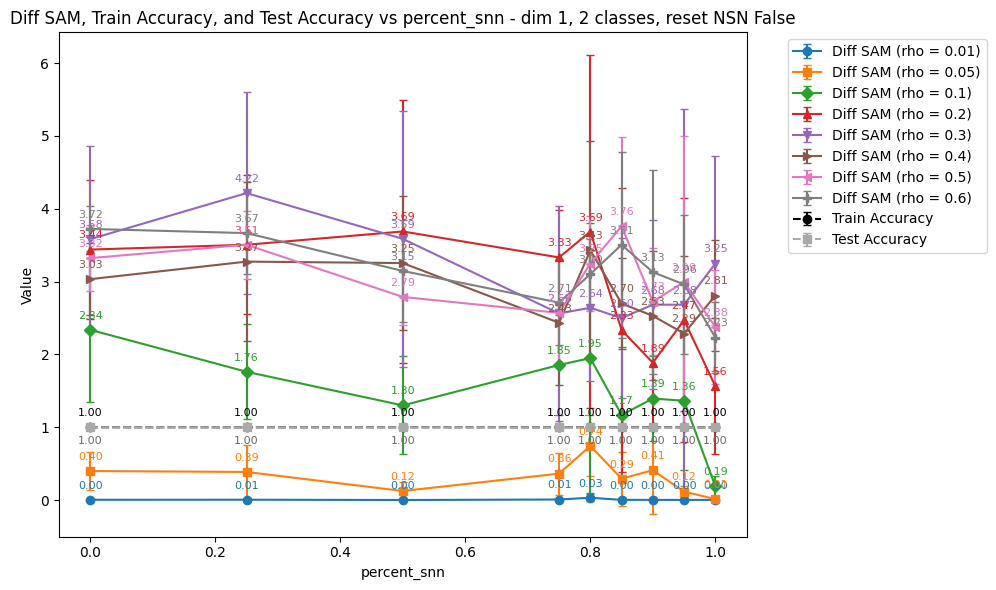

In [ ]:
import matplotlib.pyplot as plt

# Prepare the data: group by percent_snn and rho, and compute mean and std over seeds
import numpy as np

df_plot = df_final.copy()
df_plot = df_plot.dropna(subset=['test_accuracy'])

def extract_mean(val):
    if isinstance(val, list):
        return np.mean(val)
    try:
        if isinstance(val, str) and val.startswith('['):
            arr = np.array(eval(val))
            return np.mean(arr)
    except Exception:
        pass
    return val

def extract_std(val):
    if isinstance(val, list):
        return np.std(val) if len(val) > 1 else 0.0
    try:
        if isinstance(val, str) and val.startswith('['):
            arr = np.array(eval(val))
            return np.std(arr) if len(arr) > 1 else 0.0
    except Exception:
        pass
    return 0.0
df_plot['test_accuracy_std'] = df_plot['test_accuracy'].apply(extract_std)
df_plot['train_accuracy_std'] = df_plot['train_accuracy'].apply(extract_std)


# Apply extract_mean to all accuracy columns to get scalar values
df_plot['train_accuracy'] = df_plot['train_accuracy'].apply(extract_mean)
df_plot['test_accuracy'] = df_plot['test_accuracy'].apply(extract_mean)


# Group by percent_snn and rho, compute mean and std for diff_sam
grouped = df_plot.groupby(['percent_snn', 'rho'], as_index=False).agg(
    diff_sam_mean=('diff_sam', 'mean'),
    diff_sam_std=('diff_sam', 'std')
)

# Taking mean is fine because it'll be the same across rhos
acc_grouped = df_plot.groupby('percent_snn', as_index=False).agg(
    train_accuracy_mean=('train_accuracy', 'mean'),
    train_accuracy_std=('train_accuracy_std', 'mean'),
    test_accuracy_mean=('test_accuracy', 'mean'),
    test_accuracy_std=('test_accuracy_std', 'mean'),
)

marker_list = ['o', 's', 'D', '^', 'v', '>', '<', 'P', '*']
color_list = plt.cm.tab10.colors

fig, ax = plt.subplots(figsize=(10, 6))

for i, rho in enumerate(sorted(grouped['rho'].unique())):
    rho_data = grouped[grouped['rho'] == rho].sort_values('percent_snn')
    ax.errorbar(
        rho_data['percent_snn'], 
        rho_data['diff_sam_mean'], 
        yerr=rho_data['diff_sam_std'],
        label=f"Diff SAM (rho = {rho})",
        marker=marker_list[i % len(marker_list)],
        color=color_list[i % len(color_list)],
        linestyle='-',
        capsize=3
    )
    # Add number labels for diff_sam_mean
    for x, y in zip(rho_data['percent_snn'], rho_data['diff_sam_mean']):
        ax.annotate(f"{y:.2f}", (x, y), textcoords="offset points", xytext=(0, 8), ha='center', fontsize=8, color=color_list[i % len(color_list)])

# Train accuracy: black dashed line with error bars
ax.errorbar(
    acc_grouped['percent_snn'],
    acc_grouped['train_accuracy_mean'],
    yerr=acc_grouped['train_accuracy_std'],
    fmt='o--', color='black', label='Train Accuracy', capsize=3
)
# Add number labels for train accuracy
for x, y in zip(acc_grouped['percent_snn'], acc_grouped['train_accuracy_mean']):
    ax.annotate(f"{y:.2f}", (x, y), textcoords="offset points", xytext=(0, 8), ha='center', fontsize=8, color='black')

# Test accuracy: grey dashed line with error bars
ax.errorbar(
    acc_grouped['percent_snn'],
    acc_grouped['test_accuracy_mean'],
    yerr=acc_grouped['test_accuracy_std'],
    fmt='s--', color='darkgrey', label='Test Accuracy', capsize=3
)


# Add number labels for test accuracy
for x, y in zip(acc_grouped['percent_snn'], acc_grouped['test_accuracy_mean']):
    ax.annotate(f"{y:.2f}", (x, y), textcoords="offset points", xytext=(0, -12), ha='center', fontsize=8, color='dimgray')

ax.set_xlabel('percent_snn')
ax.set_ylabel('Value')
ax.set_title(f'Diff SAM, Train Accuracy, and Test Accuracy vs percent_snn - dim {num_dim}, {num_classes} classes, reset NSN {nsn_reset_val}')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
df_plot['test_accuracy_std'].unique()


array([0.])

In [ ]:
acc_grouped

,percent_snn,train_accuracy_mean,train_accuracy_std,test_accuracy_mean,test_accuracy_std
0,0.00,1.000000,0.0,1.00000,0.0
1,0.25,0.999583,0.0,0.99950,0.0
2,0.50,1.000000,0.0,0.99950,0.0
3,0.75,0.999667,0.0,0.99900,0.0
4,0.80,1.000000,0.0,0.99925,0.0
5,0.85,1.000000,0.0,0.99900,0.0
6,0.90,1.000000,0.0,0.99800,0.0
7,0.95,0.999000,0.0,0.99850,0.0
8,1.00,0.998333,0.0,0.99775,0.0
